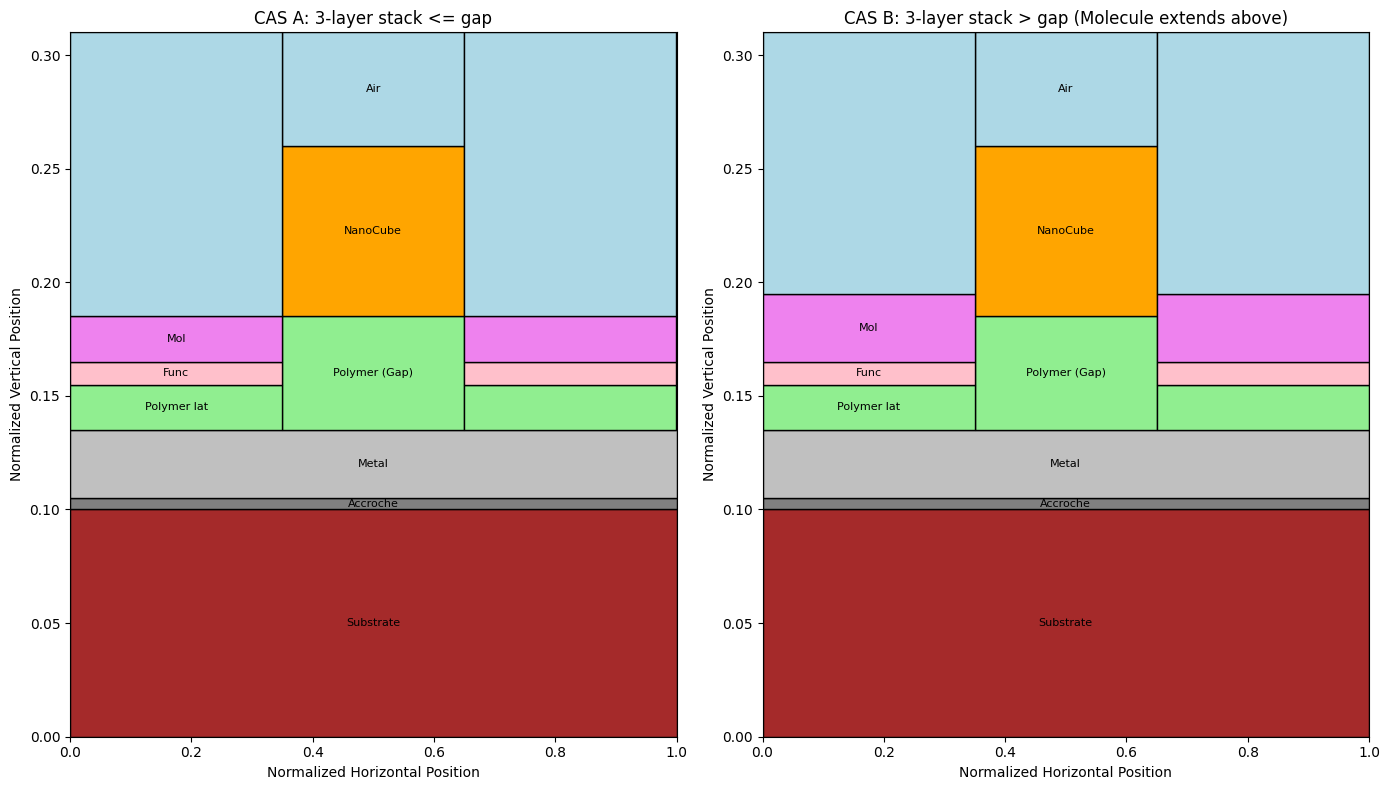

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----------------- Paramètres communs -----------------
period = 1.0
width_reso = 0.30
width_lat = (1 - width_reso) / 2

thick_gap = 0.05      # Gap central (polymère) sous le nanocube
thick_reso = 0.075     # Hauteur du nanocube

# Couches inférieures communes
thick_metal = 0.03
thick_accro = 0.005
thick_sub   = 0.1

# Position verticale : y=0 au bas du substrat
y_sub_bottom = 0
y_sub_top    = y_sub_bottom + thick_sub
y_accro_top  = y_sub_top + thick_accro
y_metal_top  = y_accro_top + thick_metal

# Le gap commence directement au-dessus du métal
y_gap_bottom = y_metal_top
y_gap_top    = y_gap_bottom + thick_gap

# Nanocube sur le gap
y_reso_bottom = y_gap_top
y_reso_top    = y_reso_bottom + thick_reso

# Air en haut
y_air_top = y_reso_top + 0.05

# ----------------- CAS A -----------------
# 3 couches latérales (Polymer, Func, Mol) total = thick_gap
thick_polyA = 0.02
thick_funcA = 0.01
thick_molA  = 0.02
# Positions verticales contiguës
yA_poly_bottom = y_gap_bottom
yA_poly_top    = yA_poly_bottom + thick_polyA
yA_func_bottom = yA_poly_top
yA_func_top    = yA_func_bottom + thick_funcA
yA_mol_bottom  = yA_func_top
yA_mol_top     = yA_mol_bottom + thick_molA  # = y_gap_bottom + 0.05 => coïncide avec y_reso_bottom

# ----------------- CAS B -----------------
# On augmente la couche moléculaire pour qu'elle dépasse le bas du nanocube
thick_polyB = 0.02
thick_funcB = 0.01
thick_molB  = 0.03  # total = 0.06 > thick_gap(0.05)
# Positions verticales contiguës
yB_poly_bottom = y_gap_bottom
yB_poly_top    = yB_poly_bottom + thick_polyB
yB_func_bottom = yB_poly_top
yB_func_top    = yB_func_bottom + thick_funcB
yB_mol_bottom  = yB_func_top
yB_mol_top     = yB_mol_bottom + thick_molB  # = y_gap_bottom + 0.06 => 0.01 plus haut que y_reso_bottom

# Fonction de dessin d'une couche
def draw_layer(ax, x, y, width, height, color, label):
    rect = patches.Rectangle((x, y), width, height, edgecolor='black', facecolor=color)
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, label, ha="center", va="center", fontsize=8)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 8))

# ------------------------------------------------------------------------------
# CAS A
# ------------------------------------------------------------------------------
ax = axA
ax.set_title("CAS A: 3-layer stack <= gap")

# Substrate, Accroche, Metal (communs)
draw_layer(ax, 0, y_sub_bottom, period, thick_sub, "brown", "Substrate")
draw_layer(ax, 0, y_sub_top, period, thick_accro, "gray", "Accroche")
draw_layer(ax, 0, y_accro_top, period, thick_metal, "silver", "Metal")

# Gap central + NanoCube
# Gap (centre)
x_cube_left = width_lat
draw_layer(ax, x_cube_left, y_gap_bottom, width_reso, thick_gap, "lightgreen", "Polymer (Gap)")
# NanoCube
draw_layer(ax, x_cube_left, y_reso_bottom, width_reso, thick_reso, "orange", "NanoCube")

# Couches latérales (gauche)
draw_layer(ax, 0, yA_poly_bottom, width_lat, thick_polyA, "lightgreen", "Polymer lat")
draw_layer(ax, 0, yA_func_bottom, width_lat, thick_funcA, "pink", "Func")
draw_layer(ax, 0, yA_mol_bottom, width_lat, thick_molA, "violet", "Mol")
# Couches latérales (droite)
draw_layer(ax, width_lat+width_reso, yA_poly_bottom, width_lat, thick_polyA, "lightgreen", "")
draw_layer(ax, width_lat+width_reso, yA_func_bottom, width_lat, thick_funcA, "pink", "")
draw_layer(ax, width_lat+width_reso, yA_mol_bottom, width_lat, thick_molA, "violet", "")

# Air
# Au centre (au-dessus du nanocube) : de y_reso_top à y_air_top
draw_layer(ax, x_cube_left, y_reso_top, width_reso, y_air_top - y_reso_top, "lightblue", "Air")
# Sur les côtés, on remplit d'air à partir du sommet de la pile latérale
# Le sommet de la pile lat = yA_mol_top = y_reso_bottom
yA_air_bottom_lat = max(y_reso_bottom, yA_mol_top)  # en CAS A, c'est égal
draw_layer(ax, 0, yA_air_bottom_lat, width_lat, y_air_top - yA_air_bottom_lat, "lightblue", "")
draw_layer(ax, width_lat+width_reso, yA_air_bottom_lat, width_lat, y_air_top - yA_air_bottom_lat, "lightblue", "")

ax.set_xlim(0, period)
ax.set_ylim(y_sub_bottom, y_air_top)
ax.set_xlabel("Normalized Horizontal Position")
ax.set_ylabel("Normalized Vertical Position")

# ------------------------------------------------------------------------------
# CAS B
# ------------------------------------------------------------------------------
ax = axB
ax.set_title("CAS B: 3-layer stack > gap (Molecule extends above)")

# Substrate, Accroche, Metal (communs)
draw_layer(ax, 0, y_sub_bottom, period, thick_sub, "brown", "Substrate")
draw_layer(ax, 0, y_sub_top, period, thick_accro, "gray", "Accroche")
draw_layer(ax, 0, y_accro_top, period, thick_metal, "silver", "Metal")

# Gap central + NanoCube
draw_layer(ax, x_cube_left, y_gap_bottom, width_reso, thick_gap, "lightgreen", "Polymer (Gap)")
draw_layer(ax, x_cube_left, y_reso_bottom, width_reso, thick_reso, "orange", "NanoCube")

# Couches latérales (gauche)
draw_layer(ax, 0, yB_poly_bottom, width_lat, thick_polyB, "lightgreen", "Polymer lat")
draw_layer(ax, 0, yB_func_bottom, width_lat, thick_funcB, "pink", "Func")
draw_layer(ax, 0, yB_mol_bottom, width_lat, thick_molB, "violet", "Mol")
# Couches latérales (droite)
draw_layer(ax, width_lat+width_reso, yB_poly_bottom, width_lat, thick_polyB, "lightgreen", "")
draw_layer(ax, width_lat+width_reso, yB_func_bottom, width_lat, thick_funcB, "pink", "")
draw_layer(ax, width_lat+width_reso, yB_mol_bottom, width_lat, thick_molB, "violet", "")

# Air
# Au centre (au-dessus du nanocube)
draw_layer(ax, x_cube_left, y_reso_top, width_reso, y_air_top - y_reso_top, "lightblue", "Air")
# Sur les côtés, on remplit d'air à partir du sommet de la pile latérale ou du bas du nano-cube, 
# whichever is higher
yB_air_bottom_lat = max(y_reso_bottom, yB_mol_top)
draw_layer(ax, 0, yB_air_bottom_lat, width_lat, y_air_top - yB_air_bottom_lat, "lightblue", "")
draw_layer(ax, width_lat+width_reso, yB_air_bottom_lat, width_lat, y_air_top - yB_air_bottom_lat, "lightblue", "")

ax.set_xlim(0, period)
ax.set_ylim(y_sub_bottom, y_air_top)
ax.set_xlabel("Normalized Horizontal Position")
ax.set_ylabel("Normalized Vertical Position")

plt.tight_layout()
plt.show()
